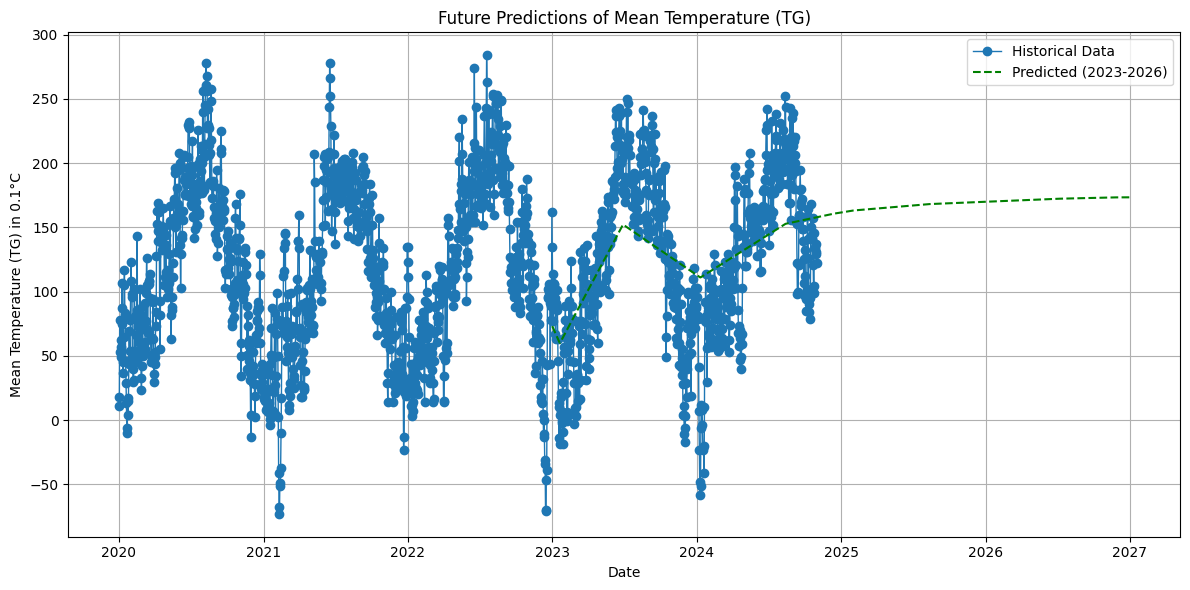

In [24]:
# Cell 7: Predict Future Values (Up to 2026)
future_dates = pd.date_range(start="2023-01-01", end="2026-12-31")
X_future = (future_dates - pd.Timestamp("2020-01-01")).days.values.reshape(-1, 1)
X_future_scaled = scaler_X.transform(X_future)

# Predict future values
y_future_scaled = mlp.predict(X_future_scaled)
y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

# Plot future predictions
plt.figure(figsize=(12, 6))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Historical Data', marker='o', linestyle='-', linewidth=1)
plt.plot(future_dates, y_future, label='Predicted (2023-2026)', color='green', linestyle='--')
plt.title('Future Predictions of Mean Temperature (TG)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (TG) in 0.1°C')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

/var/folders/31/nj5p89nx2gg_nrh13dqr10y80000gn/T/ipykernel_2950/512615193.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')


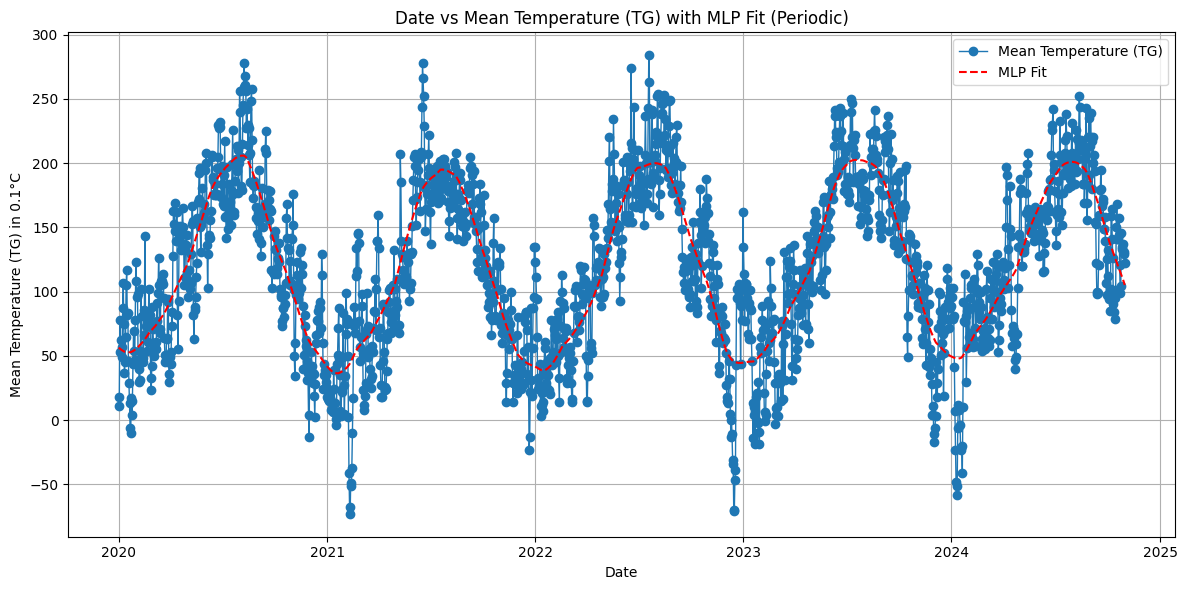

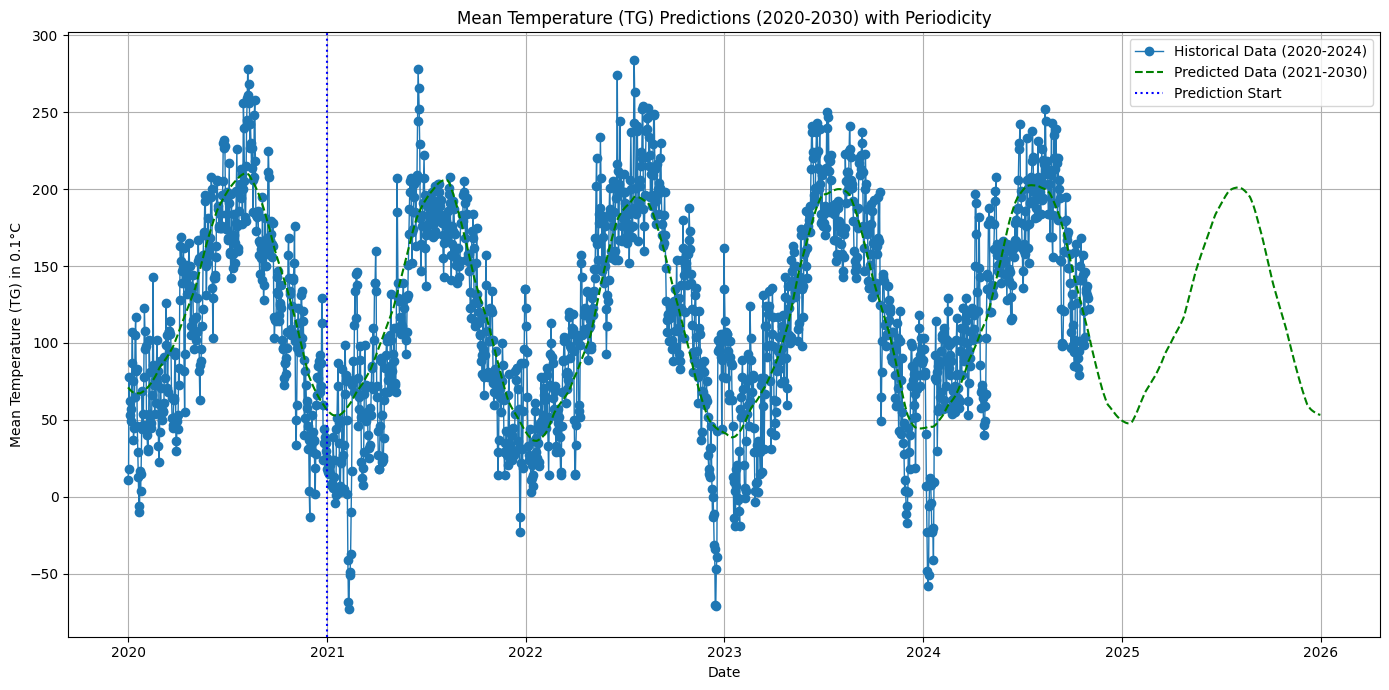

In [30]:
# Cell 1: Load Dataset and Read File
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

file_path = 'TG_SOUID121044.txt'

with open(file_path, 'r') as file:
    lines = file.readlines()

# Cell 2: Identify Data Start Index
data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line)

# Cell 3: Data Cleaning and Parsing
# Extracting only the data portion
data_lines = lines[data_start_index + 1:]

cleaned_data = []
for line in data_lines:
    # Split by commas and strip whitespace
    cleaned_line = [item.strip() for item in line.split(',')]
    # Append cleaned data if it matches the expected structure
    if len(cleaned_line) == 4:
        cleaned_data.append(cleaned_line)

columns = ["SOUID", "DATE", "TG", "Q_TG"]
data_df = pd.DataFrame(cleaned_data, columns=columns)

# Converting data types where necessary
data_df["TG"] = pd.to_numeric(data_df["TG"], errors='coerce')
data_df["Q_TG"] = pd.to_numeric(data_df["Q_TG"], errors='coerce')

# Cell 4: Data Filtering
filtered_data = data_df[data_df["Q_TG"] != 9]
filtered_data_after_2020 = filtered_data[filtered_data["DATE"].astype(int) > 20200000]
filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')

# Cell 5: Prepare Data for MLP Fitting with Periodicity
X = (filtered_data_after_2020["DATE"] - pd.Timestamp("2020-01-01")).dt.days.values.reshape(-1, 1)
y = filtered_data_after_2020["TG"].values

# Adding sine and cosine transformations to capture periodicity
X_periodic = np.hstack([
    X,
    np.sin(2 * np.pi * X / 365.25),  # Annual cycle
    np.cos(2 * np.pi * X / 365.25)
])

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_periodic)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=50000, random_state=42)
mlp.fit(X_scaled, y_scaled)

y_pred_scaled = mlp.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Cell 6: Visualization of Historical Data with MLP Fit
plt.figure(figsize=(12, 6))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Mean Temperature (TG)', marker='o', linestyle='-', linewidth=1)
plt.plot(filtered_data_after_2020["DATE"], y_pred, label='MLP Fit', color='red', linestyle='--')
plt.title('Date vs Mean Temperature (TG) with MLP Fit (Periodic)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (TG) in 0.1°C')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Cell 7: Predict Future Values (2023-2026) with Periodicity
# Generate future dates for prediction
future_dates = pd.date_range(start="2020-01-01", end="2025-12-31")
X_future = (future_dates - pd.Timestamp("2021-01-01")).days.values.reshape(-1, 1)

# Adding sine and cosine transformations for future dates
X_future_periodic = np.hstack([
    X_future,
    np.sin(2 * np.pi * X_future / 365.25),
    np.cos(2 * np.pi * X_future / 365.25)
])
X_future_scaled = scaler_X.transform(X_future_periodic)

# Predict future values
y_future_scaled = mlp.predict(X_future_scaled)
y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

# Combine historical and future data for unified visualization
plt.figure(figsize=(14, 7))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Historical Data (2020-2024)', marker='o', linestyle='-', linewidth=1)
plt.plot(future_dates, y_future, label='Predicted Data (2021-2030)', color='green', linestyle='--')
plt.axvline(x=pd.Timestamp("2021-01-01"), color='blue', linestyle=':', label='Prediction Start')
plt.title('Mean Temperature (TG) Predictions (2020-2030) with Periodicity')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (TG) in 0.1°C')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


/var/folders/31/nj5p89nx2gg_nrh13dqr10y80000gn/T/ipykernel_2950/1363997366.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')


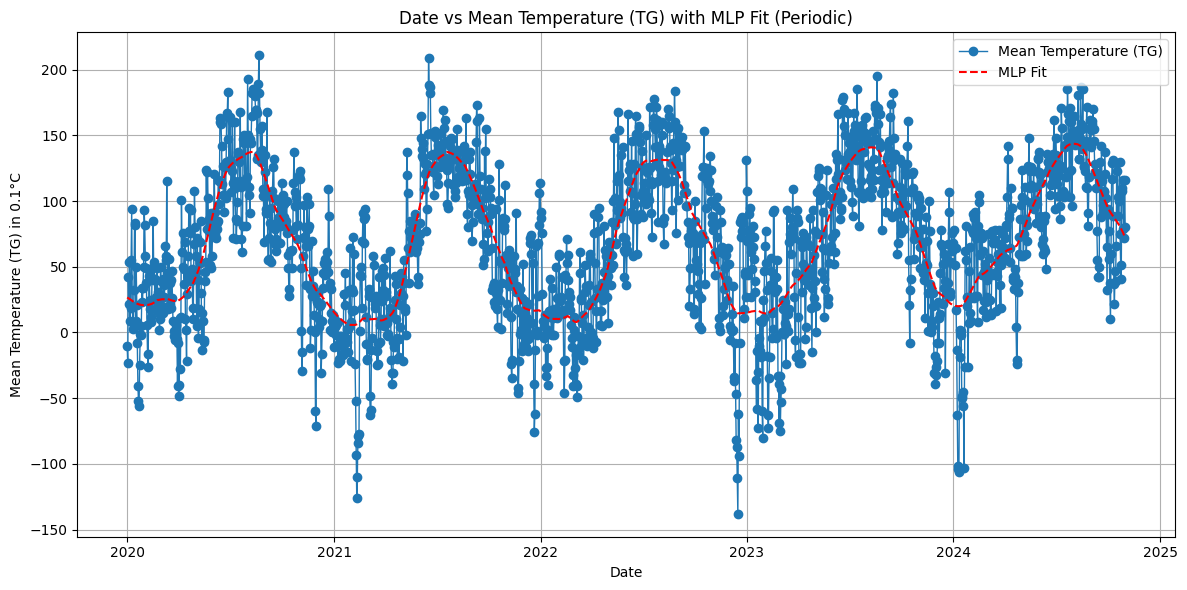

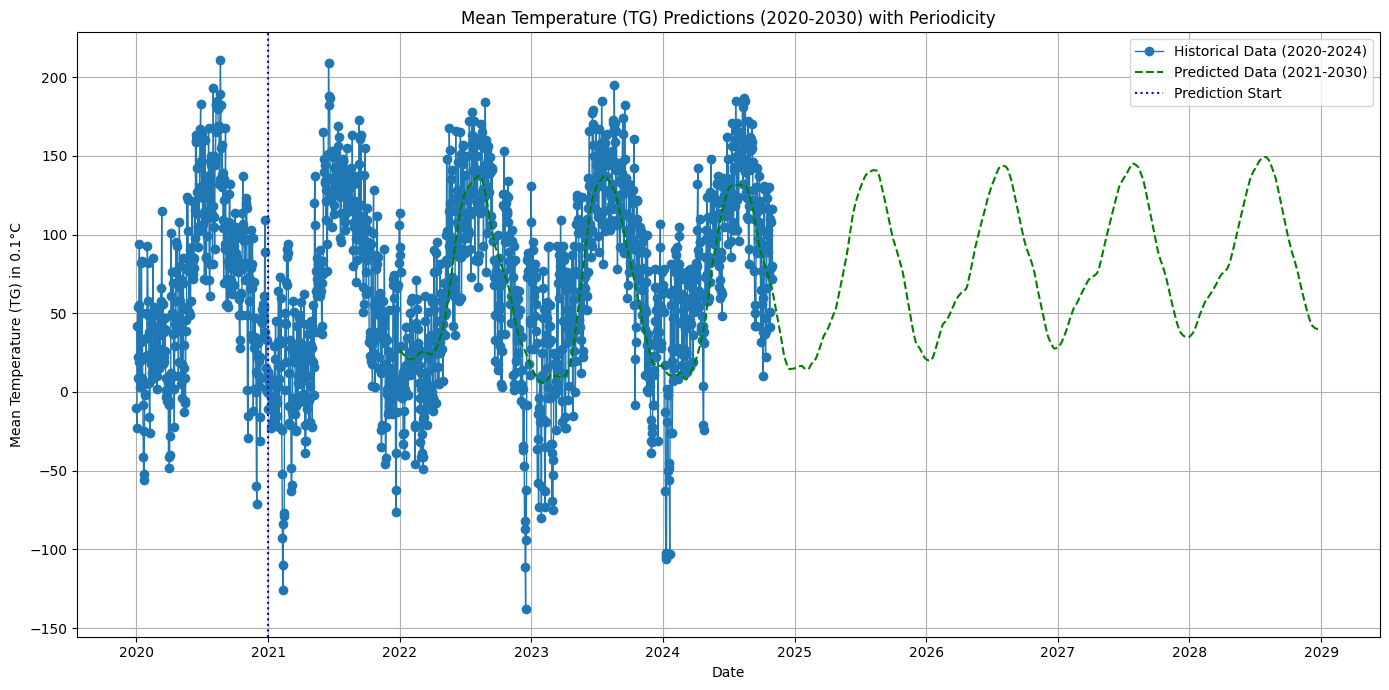

In [32]:
# Cell 1: Load Dataset and Read File
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

file_path = 'TN_SOUID121045.txt'

with open(file_path, 'r') as file:
    lines = file.readlines()

# Cell 2: Identify Data Start Index
data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line)

# Cell 3: Data Cleaning and Parsing
# Extracting only the data portion
data_lines = lines[data_start_index + 1:]

cleaned_data = []
for line in data_lines:
    # Split by commas and strip whitespace
    cleaned_line = [item.strip() for item in line.split(',')]
    # Append cleaned data if it matches the expected structure
    if len(cleaned_line) == 4:
        cleaned_data.append(cleaned_line)

columns = ["SOUID", "DATE", "TG", "Q_TG"]
data_df = pd.DataFrame(cleaned_data, columns=columns)

# Converting data types where necessary
data_df["TG"] = pd.to_numeric(data_df["TG"], errors='coerce')
data_df["Q_TG"] = pd.to_numeric(data_df["Q_TG"], errors='coerce')

# Cell 4: Data Filtering
filtered_data = data_df[data_df["Q_TG"] != 9]
filtered_data_after_2020 = filtered_data[filtered_data["DATE"].astype(int) > 20200000]
filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')

# Cell 5: Prepare Data for MLP Fitting with Periodicity
X = (filtered_data_after_2020["DATE"] - pd.Timestamp("2020-01-01")).dt.days.values.reshape(-1, 1)
y = filtered_data_after_2020["TG"].values

# Adding sine and cosine transformations to capture periodicity
X_periodic = np.hstack([
    X,
    np.sin(2 * np.pi * X / 365.25),  # Annual cycle
    np.cos(2 * np.pi * X / 365.25)
])

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_periodic)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=50000, random_state=42)
mlp.fit(X_scaled, y_scaled)

y_pred_scaled = mlp.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Cell 6: Visualization of Historical Data with MLP Fit
plt.figure(figsize=(12, 6))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Mean Temperature (TG)', marker='o', linestyle='-', linewidth=1)
plt.plot(filtered_data_after_2020["DATE"], y_pred, label='MLP Fit', color='red', linestyle='--')
plt.title('Date vs Mean Temperature (TG) with MLP Fit (Periodic)')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (TG) in 0.1°C')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Cell 7: Predict Future Values (2023-2026) with Periodicity
# Generate future dates for prediction
future_dates = pd.date_range(start="2022-01-01", end="2028-12-31")
X_future = (future_dates - pd.Timestamp("2022-01-01")).days.values.reshape(-1, 1)

# Adding sine and cosine transformations for future dates
X_future_periodic = np.hstack([
    X_future,
    np.sin(2 * np.pi * X_future / 365.25),
    np.cos(2 * np.pi * X_future / 365.25)
])
X_future_scaled = scaler_X.transform(X_future_periodic)

# Predict future values
y_future_scaled = mlp.predict(X_future_scaled)
y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

# Combine historical and future data for unified visualization
plt.figure(figsize=(14, 7))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Historical Data (2020-2024)', marker='o', linestyle='-', linewidth=1)
plt.plot(future_dates, y_future, label='Predicted Data (2021-2030)', color='green', linestyle='--')
plt.axvline(x=pd.Timestamp("2021-01-01"), color='blue', linestyle=':', label='Prediction Start')
plt.title('Mean Temperature (TG) Predictions (2020-2030) with Periodicity')
plt.xlabel('Date')
plt.ylabel('Mean Temperature (TG) in 0.1°C')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


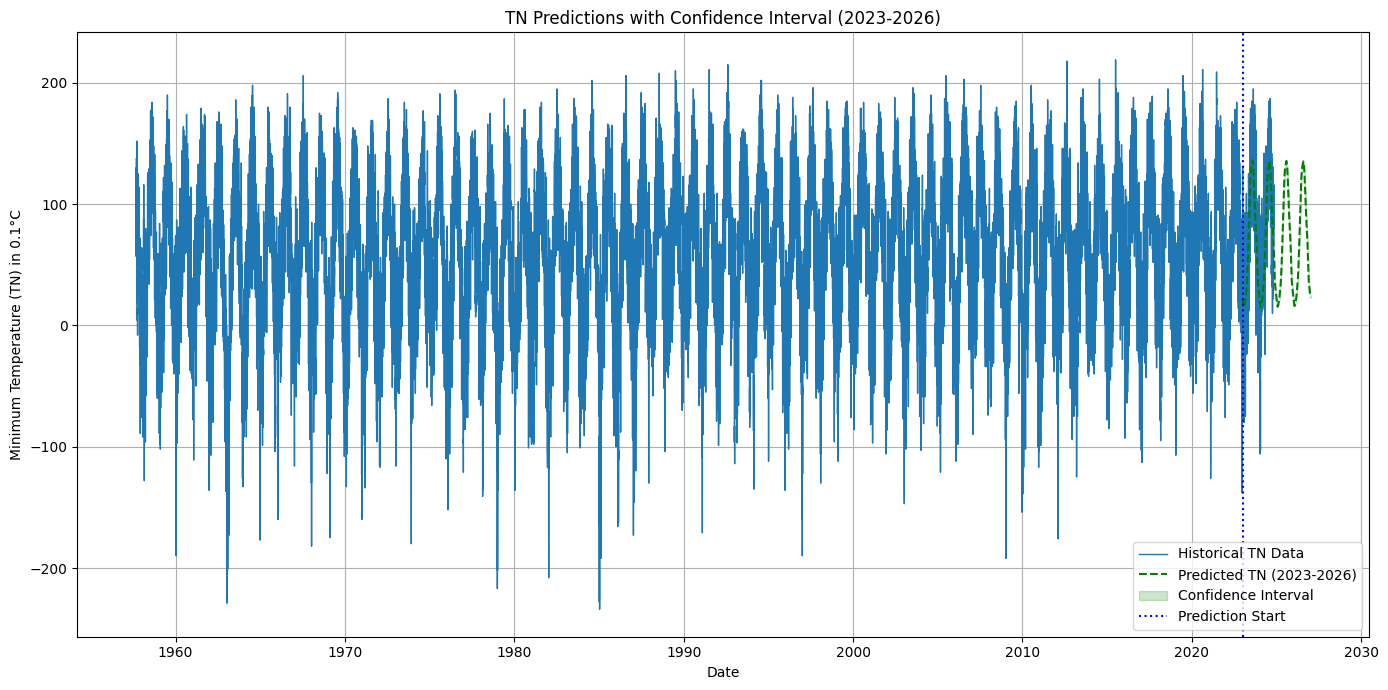

In [1]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# File paths
file_tn_path = 'TN_SOUID121045.txt'
file_tx_path = 'TX_SOUID121046.txt'

# Function to load and process data
def load_and_process(file_path, temp_col, quality_col):
    # Read file
    with open(file_path, 'r') as file:
        lines = file.readlines()
    
    # Identify data start
    data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line) + 1
    
    # Extract relevant data
    data_lines = lines[data_start_index:]
    data = []
    for line in data_lines:
        parts = line.split(",")
        if len(parts) >= 4:
            data.append([parts[0].strip(), parts[1].strip(), parts[2].strip(), parts[3].strip()])

    # Create DataFrame
    columns = ["SOUID", "DATE", temp_col, quality_col]
    df = pd.DataFrame(data, columns=columns)

    # Convert to appropriate types
    df[temp_col] = pd.to_numeric(df[temp_col], errors='coerce')
    df[quality_col] = pd.to_numeric(df[quality_col], errors='coerce')

    # Filter valid data
    df = df[df[quality_col] == 0]
    df["DATE"] = pd.to_datetime(df["DATE"], format='%Y%m%d')
    
    return df

# Load TN and TX data
tn_data = load_and_process(file_tn_path, "TN", "Q_TN")
tx_data = load_and_process(file_tx_path, "TX", "Q_TX")

# Combine TN and TX for analysis
combined_data = pd.merge(tn_data[["DATE", "TN"]], tx_data[["DATE", "TX"]], on="DATE")

# Prepare for MLP fitting
X = (combined_data["DATE"] - pd.Timestamp("2020-01-01")).dt.days.values.reshape(-1, 1)
y = combined_data["TN"].values  # Using TN as an example for modeling

# Adding periodic features
X_periodic = np.hstack([
    X,
    np.sin(2 * np.pi * X / 365.25),  # Annual cycle
    np.cos(2 * np.pi * X / 365.25)
])

# Scale features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_periodic)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

# Train MLP
mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=5000, random_state=42)
mlp.fit(X_scaled, y_scaled)

# Predict and calculate errors
y_pred_scaled = mlp.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Calculate error (standard deviation of residuals)
residuals = y - scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).ravel()
std_dev = np.std(residuals)

# Future predictions with error bars
future_dates = pd.date_range(start="2023-01-01", end="2026-12-31")
X_future = (future_dates - pd.Timestamp("2020-01-01")).days.values.reshape(-1, 1)
X_future_periodic = np.hstack([
    X_future,
    np.sin(2 * np.pi * X_future / 365.25),
    np.cos(2 * np.pi * X_future / 365.25)
])
X_future_scaled = scaler_X.transform(X_future_periodic)

y_future_scaled = mlp.predict(X_future_scaled)
y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

# Create upper and lower bounds for error bars
upper_bound = y_future + std_dev
lower_bound = y_future - std_dev

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(combined_data["DATE"], combined_data["TN"], label="Historical TN Data", linestyle='-', linewidth=1)
plt.plot(future_dates, y_future, label="Predicted TN (2023-2026)", color='green', linestyle='--')
plt.fill_between(future_dates, lower_bound, upper_bound, color='green', alpha=0.2, label="Confidence Interval")
plt.axvline(x=pd.Timestamp("2023-01-01"), color="blue", linestyle=":", label="Prediction Start")
plt.title("TN Predictions with Confidence Interval (2023-2026)")
plt.xlabel("Date")
plt.ylabel("Minimum Temperature (TN) in 0.1°C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


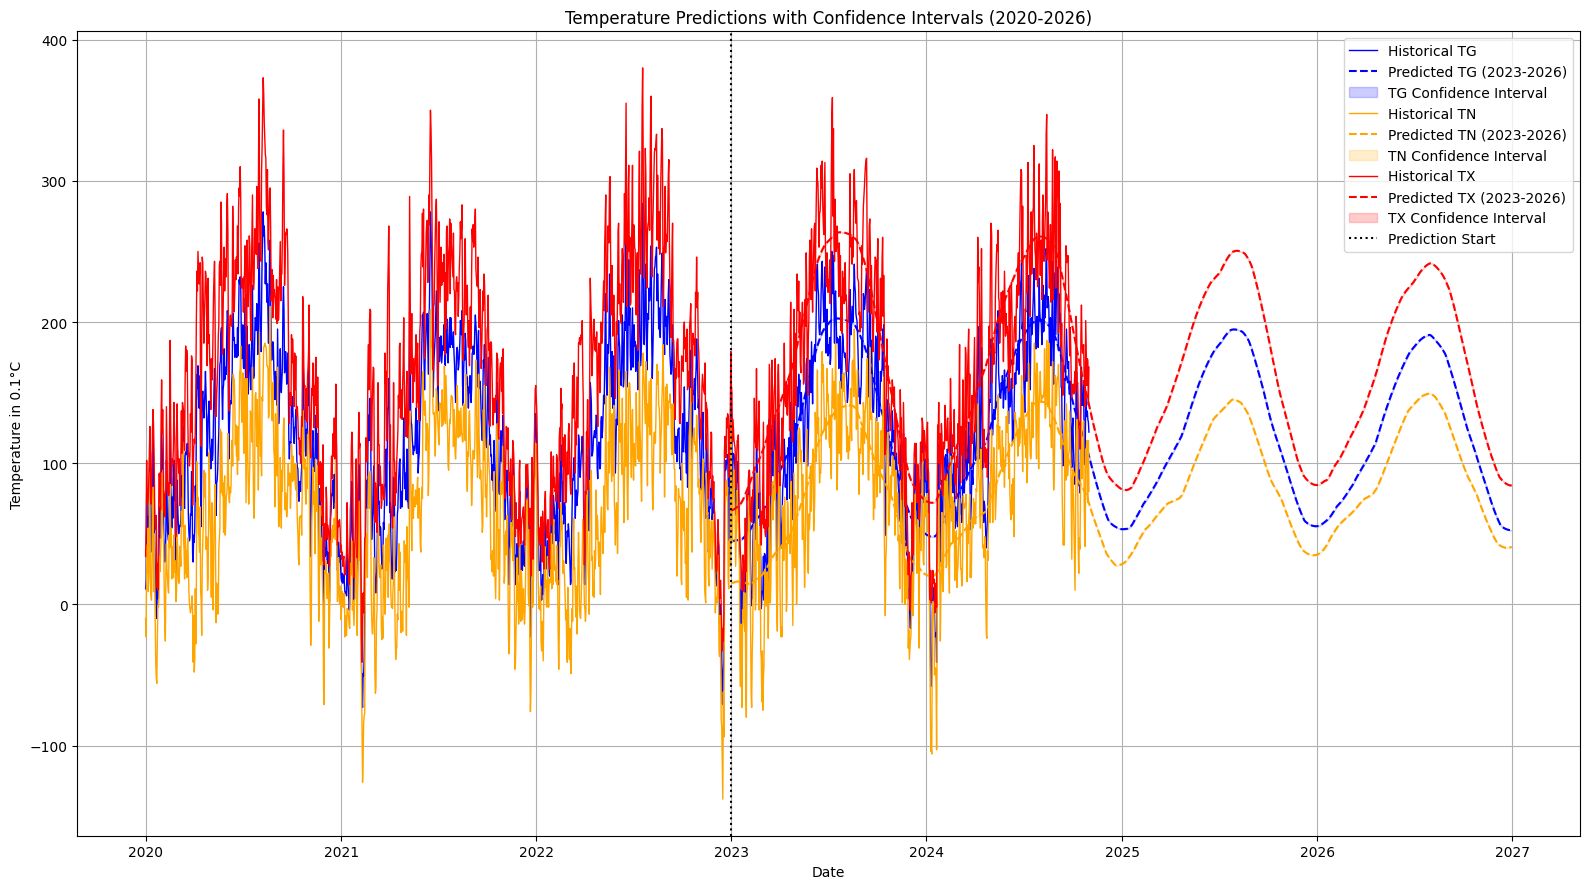

In [3]:
import pandas as pd
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# File paths
file_tg_path = 'TG_SOUID121044.txt'
file_tn_path = 'TN_SOUID121045.txt'
file_tx_path = 'TX_SOUID121046.txt'

# Function to load and process data
def load_and_process(file_path, temp_col, quality_col):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Identify data start
    data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line) + 1

    # Extract relevant data
    data_lines = lines[data_start_index:]
    data = []
    for line in data_lines:
        parts = line.split(",")
        if len(parts) >= 4:
            data.append([parts[0].strip(), parts[1].strip(), parts[2].strip(), parts[3].strip()])

    # Create DataFrame
    columns = ["SOUID", "DATE", temp_col, quality_col]
    df = pd.DataFrame(data, columns=columns)

    # Convert to appropriate types
    df[temp_col] = pd.to_numeric(df[temp_col], errors='coerce')
    df[quality_col] = pd.to_numeric(df[quality_col], errors='coerce')

    # Filter valid data
    df = df[df[quality_col] == 0]
    df["DATE"] = pd.to_datetime(df["DATE"], format='%Y%m%d')

    # Filter data from 2020 onwards
    df = df[df["DATE"] >= "2020-01-01"]
    return df

# Load datasets
tg_data = load_and_process(file_tg_path, "TG", "Q_TG")
tn_data = load_and_process(file_tn_path, "TN", "Q_TN")
tx_data = load_and_process(file_tx_path, "TX", "Q_TX")

# Combine datasets
combined_data = pd.merge(tg_data[["DATE", "TG"]], tn_data[["DATE", "TN"]], on="DATE")
combined_data = pd.merge(combined_data, tx_data[["DATE", "TX"]], on="DATE")

# Prepare for MLP fitting
X = (combined_data["DATE"] - pd.Timestamp("2020-01-01")).dt.days.values.reshape(-1, 1)

# Adding periodic features
X_periodic = np.hstack([
    X,
    np.sin(2 * np.pi * X / 365.25),  # Annual cycle
    np.cos(2 * np.pi * X / 365.25)
])

# Scale features
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_periodic)

# Initialize plot
plt.figure(figsize=(16, 9))

# Loop through each temperature variable
for variable, color in zip(["TG", "TN", "TX"], ["blue", "orange", "red"]):
    # Prepare data for the current variable
    y = combined_data[variable].values
    y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

    # Train MLP
    mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=5000, random_state=42)
    mlp.fit(X_scaled, y_scaled)

    # Historical predictions
    y_pred_scaled = mlp.predict(X_scaled)
    y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

    # Residuals and error calculation
    residuals = y - scaler_y.inverse_transform(y_scaled.reshape(-1, 1)).ravel()
    std_dev = np.std(residuals)

    # Future predictions
    future_dates = pd.date_range(start="2023-01-01", end="2026-12-31")
    X_future = (future_dates - pd.Timestamp("2020-01-01")).days.values.reshape(-1, 1)
    X_future_periodic = np.hstack([
        X_future,
        np.sin(2 * np.pi * X_future / 365.25),
        np.cos(2 * np.pi * X_future / 365.25)
    ])
    X_future_scaled = scaler_X.transform(X_future_periodic)
    y_future_scaled = mlp.predict(X_future_scaled)
    y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

    # Upper and lower bounds
    upper_bound = y_future + std_dev
    lower_bound = y_future - std_dev

    # Plot historical and predicted data
    plt.plot(combined_data["DATE"], combined_data[variable], label=f"Historical {variable}", linestyle='-', linewidth=1, color=color)
    plt.plot(future_dates, y_future, label=f"Predicted {variable} (2023-2026)", linestyle='--', color=color)
    plt.fill_between(future_dates, lower_bound, upper_bound, color=color, alpha=0.2, label=f"{variable} Confidence Interval")

# Mark prediction start
plt.axvline(x=pd.Timestamp("2023-01-01"), color="black", linestyle=":", label="Prediction Start")

# Add titles and labels
plt.title("Temperature Predictions with Confidence Intervals (2020-2026)")
plt.xlabel("Date")
plt.ylabel("Temperature in 0.1°C")
plt.legend()
plt.grid(True)
plt.tight_layout()

# Show plot
plt.show()


/var/folders/31/nj5p89nx2gg_nrh13dqr10y80000gn/T/ipykernel_36903/1179679839.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')


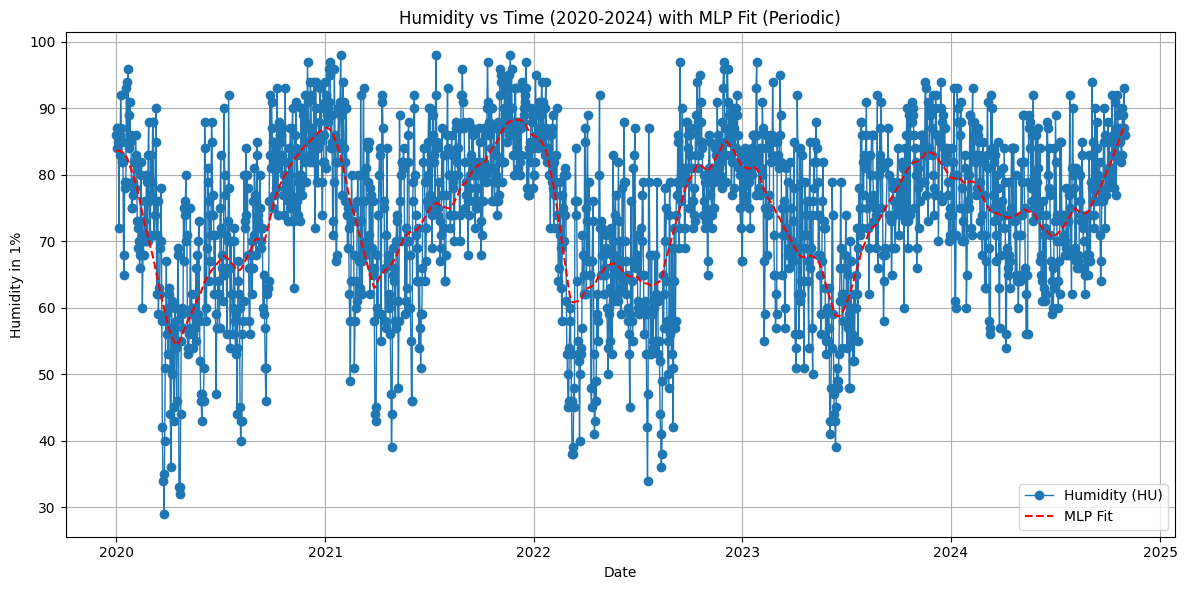

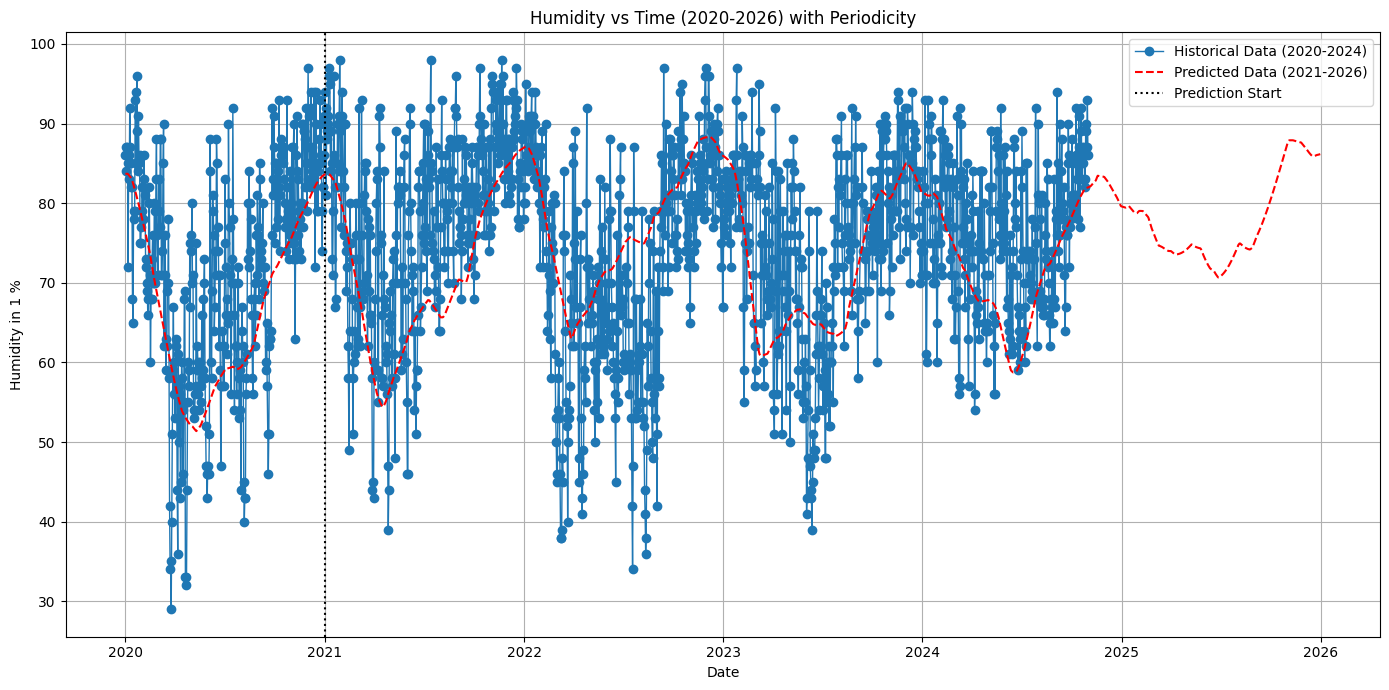

In [9]:
# Cell 1: Load Dataset and Read File
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
import numpy as np

file_path = 'HU_SOUID121047.txt'

with open(file_path, 'r') as file:
    lines = file.readlines()

# Cell 2: Identify Data Start Index
data_start_index = next(i for i, line in enumerate(lines) if "SOUID" in line and "DATE" in line)

# Cell 3: Data Cleaning and Parsing
# Extracting only the data portion
data_lines = lines[data_start_index + 1:]

cleaned_data = []
for line in data_lines:
    # Split by commas and strip whitespace
    cleaned_line = [item.strip() for item in line.split(',')]
    # Append cleaned data if it matches the expected structure
    if len(cleaned_line) == 4:
        cleaned_data.append(cleaned_line)

columns = ["SOUID", "DATE", "TG", "Q_TG"]
data_df = pd.DataFrame(cleaned_data, columns=columns)

# Converting data types where necessary
data_df["TG"] = pd.to_numeric(data_df["TG"], errors='coerce')
data_df["Q_TG"] = pd.to_numeric(data_df["Q_TG"], errors='coerce')

# Cell 4: Data Filtering
filtered_data = data_df[data_df["Q_TG"] != 9]
filtered_data_after_2020 = filtered_data[filtered_data["DATE"].astype(int) > 20200000]
filtered_data_after_2020["DATE"] = pd.to_datetime(filtered_data_after_2020["DATE"], format='%Y%m%d')

# Cell 5: Prepare Data for MLP Fitting with Periodicity
X = (filtered_data_after_2020["DATE"] - pd.Timestamp("2020-01-01")).dt.days.values.reshape(-1, 1)
y = filtered_data_after_2020["TG"].values

# Adding sine and cosine transformations to capture periodicity
X_periodic = np.hstack([
    X,
    np.sin(2 * np.pi * X / 365.25),  # Annual cycle
    np.cos(2 * np.pi * X / 365.25)
])

scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_scaled = scaler_X.fit_transform(X_periodic)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1)).ravel()

mlp = MLPRegressor(hidden_layer_sizes=(50,), max_iter=50000, random_state=42)
mlp.fit(X_scaled, y_scaled)

y_pred_scaled = mlp.predict(X_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()

# Cell 6: Visualization of Historical Data with MLP Fit
plt.figure(figsize=(12, 6))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Humidity (HU)', marker='o', linestyle='-', linewidth=1)
plt.plot(filtered_data_after_2020["DATE"], y_pred, label='MLP Fit', color='red', linestyle='--')
plt.title('Humidity vs Time (2020-2024) with MLP Fit (Periodic)')
plt.xlabel('Date')
plt.ylabel('Humidity in 1%')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Cell 7: Predict Future Values (2023-2026) with Periodicity
# Generate future dates for prediction
future_dates = pd.date_range(start="2020-01-01", end="2025-12-31")
X_future = (future_dates - pd.Timestamp("2021-01-01")).days.values.reshape(-1, 1)

# Adding sine and cosine transformations for future dates
X_future_periodic = np.hstack([
    X_future,
    np.sin(2 * np.pi * X_future / 365.25),
    np.cos(2 * np.pi * X_future / 365.25)
])
X_future_scaled = scaler_X.transform(X_future_periodic)

# Predict future values
y_future_scaled = mlp.predict(X_future_scaled)
y_future = scaler_y.inverse_transform(y_future_scaled.reshape(-1, 1)).ravel()

# Combine historical and future data for unified visualization
plt.figure(figsize=(14, 7))
plt.plot(filtered_data_after_2020["DATE"], filtered_data_after_2020["TG"], label='Historical Data (2020-2024)', marker='o', linestyle='-', linewidth=1)
plt.plot(future_dates, y_future, label='Predicted Data (2021-2026)', color='red', linestyle='--')
plt.axvline(x=pd.Timestamp("2021-01-01"), color='black', linestyle=':', label='Prediction Start')
plt.title('Humidity vs Time (2020-2026) with Periodicity')
plt.xlabel('Date')
plt.ylabel('Humidity in 1 %')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()
